# EEG Biomarker-Based Classification of Schizophrenia (SCZ vs Control)

## Goal
Build a Machine Learning pipeline to classify **Schizophrenia (SCZ)** vs **Healthy Control** subjects using EEG-derived biomarkers/features.

## Key Steps
1. Data Cleaning  
2. Train/Test Split  
3. Data Preprocessing  
4. Feature Selection using `SelectKBest`  
5. Model Training  
6. Model Evaluation using:
   - F1 Score
   - ROC–AUC Score

## Notes
- Results are exploratory in nature.
- Small dataset size (**N = 38**) requires careful validation and interpretation.
- Performance metrics may vary due to limited sample size.

In [25]:
# Step 1: Imports & Setup
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
RANDOM_STATE = 42
TARGET = "DIS"   # True = SCZ, False = Control
DATA_PATH = r"C:\Users\AB\OneDrive\EEG-Schizophrenia ML Project\EEG-Clinical-Decision-Support-Feasibility\data\NREM_Schizophrenia.csv"

In [26]:
# Step 2: loading the Dataset
df_raw = pd.read_csv("NREM_Schizophrenia.csv")
print(df_raw.shape)
df_raw.head(3)

(130, 2897)


,DIS,AGE,SEX,DENS_11_AF3,DENS_11_AF4,DENS_11_AFZ,DENS_11_C1,DENS_11_C2,DENS_11_C3,DENS_11_C4,DENS_11_C5,DENS_11_C6,DENS_11_CP1,DENS_11_CP2,DENS_11_CP3,DENS_11_CP4,DENS_11_CP5,DENS_11_CP6,DENS_11_CPZ,DENS_11_CZ,DENS_11_F1,DENS_11_F2,DENS_11_F3,DENS_11_F4,DENS_11_F5,DENS_11_F6,DENS_11_F7,DENS_11_F8,DENS_11_FC1,DENS_11_FC2,DENS_11_FC3,DENS_11_FC4,DENS_11_FC5,DENS_11_FC6,DENS_11_FCZ,DENS_11_FPZ,DENS_11_FT7,DENS_11_FT8,DENS_11_FZ,DENS_11_FP1,DENS_11_FP2,DENS_11_O1,DENS_11_O2,DENS_11_OZ,DENS_11_P1,DENS_11_P2,DENS_11_P3,DENS_11_P4,DENS_11_P5,DENS_11_P6,DENS_11_P7,DENS_11_P8,DENS_11_PO3,DENS_11_PO4,DENS_11_POZ,DENS_11_PZ,DENS_11_T7,DENS_11_T8,DENS_11_TP7,DENS_11_TP8,DENS_15_AF3,DENS_15_AF4,DENS_15_AFZ,DENS_15_C1,DENS_15_C2,DENS_15_C3,DENS_15_C4,DENS_15_C5,DENS_15_C6,DENS_15_CP1,DENS_15_CP2,DENS_15_CP3,DENS_15_CP4,DENS_15_CP5,DENS_15_CP6,DENS_15_CPZ,DENS_15_CZ,DENS_15_F1,DENS_15_F2,DENS_15_F3,DENS_15_F4,DENS_15_F5,DENS_15_F6,DENS_15_F7,DENS_15_F8,DENS_15_FC1,DENS_15_FC2,DENS_15_FC3,DENS_15_FC4,DENS_15_FC5,DENS_15_FC6,DENS_15_FCZ,DENS_15_FPZ,DENS_15_FT7,DENS_15_FT8,DENS_15_FZ,DENS_15_FP1,DENS_15_FP2,DENS_15_O1,DENS_15_O2,...,P50_RATIO_F4,P50_RATIO_F6,P50_RATIO_F8,P50_RATIO_FT7,P50_RATIO_FC5,P50_RATIO_FC3,P50_RATIO_FC1,P50_RATIO_FC2,P50_RATIO_FC4,P50_RATIO_FC6,P50_RATIO_FT8,P50_RATIO_T7,P50_RATIO_C5,P50_RATIO_C3,P50_RATIO_C1,P50_RATIO_C2,P50_RATIO_C4,P50_RATIO_C6,P50_RATIO_T8,P50_RATIO_TP7,P50_RATIO_CP5,P50_RATIO_CP3,P50_RATIO_CP1,P50_RATIO_CP2,P50_RATIO_CP4,P50_RATIO_CP6,P50_RATIO_TP8,P50_RATIO_P7,P50_RATIO_P5,P50_RATIO_P3,P50_RATIO_P1,P50_RATIO_P2,P50_RATIO_P4,P50_RATIO_P6,P50_RATIO_P8,P50_RATIO_PO3,P50_RATIO_PO4,P50_RATIO_O1,P50_RATIO_O2,P50_RATIO_AFZ,P50_RATIO_FZ,P50_RATIO_FCZ,P50_RATIO_CZ,P50_RATIO_CPZ,P50_RATIO_PZ,P50_RATIO_POZ,P50_RATIO_OZ,MMN_AMP_AF3,MMN_AMP_AF4,MMN_AMP_F7,MMN_AMP_F5,MMN_AMP_F3,MMN_AMP_F1,MMN_AMP_F2,MMN_AMP_F4,MMN_AMP_F6,MMN_AMP_F8,MMN_AMP_FT7,MMN_AMP_FC5,MMN_AMP_FC3,MMN_AMP_FC1,MMN_AMP_FC2,MMN_AMP_FC4,MMN_AMP_FC6,MMN_AMP_FT8,MMN_AMP_T7,MMN_AMP_C5,MMN_AMP_C3,MMN_AMP_C1,MMN_AMP_C2,MMN_AMP_C4,MMN_AMP_C6,MMN_AMP_T8,MMN_AMP_TP7,MMN_AMP_CP5,MMN_AMP_CP3,MMN_AMP_CP1,MMN_AMP_CP2,MMN_AMP_CP4,MMN_AMP_CP6,MMN_AMP_TP8,MMN_AMP_P7,MMN_AMP_P5,MMN_AMP_P3,MMN_AMP_P1,MMN_AMP_P2,MMN_AMP_P4,MMN_AMP_P6,MMN_AMP_P8,MMN_AMP_PO3,MMN_AMP_PO4,MMN_AMP_O1,MMN_AMP_O2,MMN_AMP_FZ,MMN_AMP_FCZ,MMN_AMP_CZ,MMN_AMP_CPZ,MMN_AMP_PZ,MMN_AMP_POZ,MMN_AMP_OZ
0,True,25-30,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.773251,0.564801,0.509912,0.896744,1.452789,0.519407,0.675099,0.782663,0.778377,0.734688,0.578094,1.097838,1.070032,0.729881,0.761640,0.801657,0.897006,0.817392,0.970325,0.927901,0.732031,0.760123,0.770741,0.889287,0.914739,0.910522,1.257430,0.986806,0.765402,0.761067,0.759881,0.947985,0.896533,1.148335,1.173457,0.740428,0.812295,0.847564,0.799814,0.678089,0.795868,0.845739,0.867701,0.753652,0.766623,0.796136,0.763370,0.547633,-0.389284,-0.080603,-0.028978,-0.147984,-0.146911,0.072777,0.012356,0.080110,0.103384,-0.231884,-0.462682,-0.769511,-0.587407,-0.112367,0.033919,0.057412,0.082541,-0.212079,-1.123533,-1.060301,-0.859289,-0.287388,-0.350359,-0.247817,0.452844,0.098301,-1.006965,-0.912272,-0.684736,-0.370845,-0.325121,-0.324902,0.156111,0.014411,-0.597628,-0.588497,-0.543239,-0.358674,-0.347481,-0.815184,-0.813223,-0.538514,-0.336279,-0.374607,-0.398541,0.086445,-0.254316,-0.389502,-0.375777,-0.452731,-0.395099,-0.371746
1,True,40-45,F,2.233645,2.359813,2.266355,0.630841,0.677570,0.714953,0.626168,0.901869,0.850467,0.490654,0.504673,0.528037,0.485981,0.621495,0.621495,0.476636,0.658879,1.574766,1.355140,1.761682,1.827103,2.317757,1.920561,2.341121,2.079439,1.084112,1.009346,1.686916,1.014019,1.607

In [27]:
print(df_raw['DIS'].value_counts())

DIS
True     72
False    58
Name: count, dtype: int64


In [28]:
# Step 3: Schema & Missing Values
print("dtypes:\n", df_raw.dtypes.value_counts())
print("\nnulls (top 20):\n", df_raw.isna().sum().sort_values(ascending=False).head(20))
if TARGET in df_raw.columns:
    print("\nTARGET counts:\n", df_raw[TARGET].value_counts(dropna=False))

dtypes:
 float64    2894
object        2
bool          1
Name: count, dtype: int64

nulls (top 20):
 P50_RATIO_T7     45
P50_RATIO_TP7    42
P50_RATIO_T8     41
P50_RATIO_FT8    40
P50_RATIO_FT7    39
P50_RATIO_TP8    39
P50_RATIO_P7     38
P50_RATIO_F8     38
P50_RATIO_F7     38
P50_RATIO_O2     36
P50_RATIO_P8     36
P50_RATIO_O1     36
P50_RATIO_CP5    35
P50_RATIO_PO4    34
P50_RATIO_POZ    33
P50_RATIO_FC6    33
P50_RATIO_P6     33
P50_RATIO_OZ     33
P50_RATIO_P4     32
P50_RATIO_C5     32
dtype: int64

TARGET counts:
 DIS
True     72
False    58
Name: count, dtype: int64


In [29]:
# Step 4: Making a Working Copy & Basic Cleaning
df = df_raw.copy()

# Drop duplicate rows if any
df = df.drop_duplicates()

# Strip whitespace from column names
for c in df.select_dtypes(include=["object"]).columns:
    df[c] = df[c].astype(str).str.strip()
print("after dedupe:", df.shape)

after dedupe: (130, 2897)


In [30]:
# Step 5: REmoving Constant Columns
constant_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
df = df.drop(columns=constant_cols)
print("dropped constant cols:", len(constant_cols))

dropped constant cols: 0


In [31]:
# Step 6: Removing Columns with Too Many Missing Values
COL_MISSING_THRESH = 0.60
missing_frac = df.isna().mean()
high_missing_cols = missing_frac[missing_frac > COL_MISSING_THRESH].index.tolist()
if TARGET in high_missing_cols:
    high_missing_cols.remove(TARGET)
df = df.drop(columns=high_missing_cols)
print("dropped high-missing cols:", len(high_missing_cols), "| shape:", df.shape)

dropped high-missing cols: 0 | shape: (130, 2897)


In [32]:
# Step 7: Seperating Features & Target (Avoiding Data Leakage)
LEAK_OR_ID_COLS = []  # e.g., ["subject_id"]
y = df[TARGET].copy()
X = df.drop(columns=[TARGET] + [c for c in LEAK_OR_ID_COLS if c in df.columns])
print("X:", X.shape, "| y:", y.shape)

X: (130, 2896) | y: (130,)


In [33]:
# Step 8: Train-Test Split (Before Any Scaling or Imputation)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print("train:", X_train.shape, " test:", X_test.shape)

train: (104, 2896)  test: (26, 2896)


In [34]:
# Step 9: Identifying Numerical and Categorial Columns
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()
print("numeric:", len(num_cols), "categorical:", len(cat_cols))

numeric: 2894 categorical: 2


In [35]:
# Step 10: Handling Rare Categories (Fit on Train, Apply on Test)
RARE_THRESH = 0.01
cat_maps = {}
for c in cat_cols:
    freqs = X_train[c].value_counts(normalize=True, dropna=False)
    keep = set(freqs[freqs >= RARE_THRESH].index.tolist())
    cat_maps[c] = keep
    X_train[c] = X_train[c].where(X_train[c].isin(keep), "__OTHER__")
    X_test[c]  = X_test[c].where(X_test[c].isin(keep), "__OTHER__")

In [36]:
# Step 11: Selecting Curated EEG Biomarker Features
key_features = [
    "DENS_11_AF3", "DENS_11_AF4",  # frontal spindle density
    "EEG_MEAN", "EEG_STD",         # overall EEG power & variance
    # "MMN_AMP_PZ", "MMN_AMP_OZ",  # include if present
]
key_features = [c for c in key_features if c in X_train.columns]
print("key_features:", key_features)

key_features: ['DENS_11_AF3', 'DENS_11_AF4']


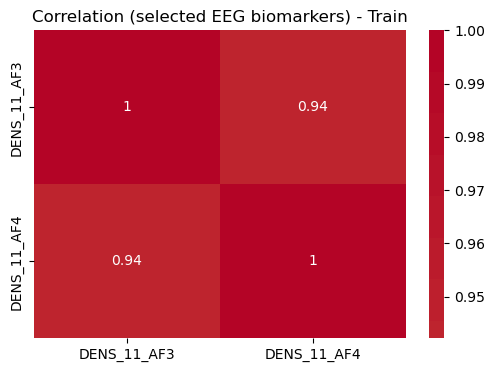

In [37]:
# Step 12: Checking Correlation Among Key Features (Train Set Only)
corr = X_train[key_features].corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True)
plt.title("Correlation (selected EEG biomarkers) - Train")
plt.show()

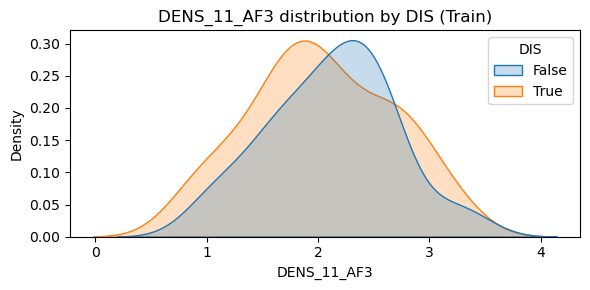

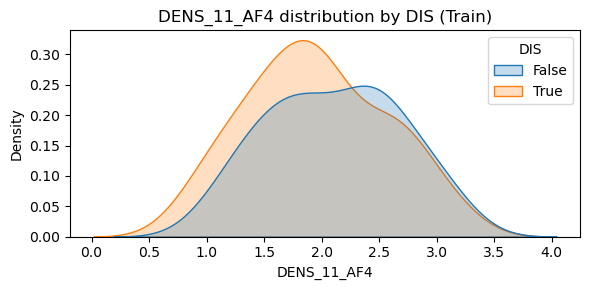

In [38]:
# Step 13: Visualizing Class-wise Feature Distributions (Train Set Only)
for col in key_features:
    plt.figure(figsize=(6,3))
    sns.kdeplot(x=X_train[col], hue=y_train, fill=True)
    plt.title(f"{col} distribution by {TARGET} (Train)")
    plt.tight_layout()
    plt.show()

In [39]:
# Step 14: Building the Column Transformer (Preprocessing Pipeline)
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols)
    ],
    remainder="drop"
)

In [40]:
# Step 15: Feature Selection Using SelectKBest (ANOVA F-test)
K = 100
selector = SelectKBest(score_func=f_classif, k=100)

In [41]:
# Step 16: Defining the Candidate Models
models = {
    "LogReg": LogisticRegression(max_iter=1000, n_jobs=None),
    "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(random_state=RANDOM_STATE),
    "SVM": SVC(probability=True, random_state=RANDOM_STATE)
}

In [42]:
# Step 17: Creating a Helper Function to Build a Pipeline
from sklearn.base import clone

def make_pipeline(model):
    return Pipeline([
        ("prep", preprocess),
        ("select", selector),
        ("model", clone(model))
    ])

In [43]:
# Step 18: Training Models and Evaluating on the Test Set

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

results = []
for name, model in models.items():
    pipe = make_pipeline(model)
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    print(f"\n=== {name} ===")
    print("Accuracy:", round(acc, 3), " | AUC:", round(auc, 3))
    print(classification_report(y_test, y_pred, digits=3))

    results.append((name, acc, auc, pipe))

results_sorted = sorted(results, key=lambda x: (x[2], x[1]), reverse=True)
results_sorted[:3]


=== LogReg ===
Accuracy: 0.808  | AUC: 0.875
              precision    recall  f1-score   support

       False      0.706     1.000     0.828        12
        True      1.000     0.643     0.783        14

    accuracy                          0.808        26
   macro avg      0.853     0.821     0.805        26
weighted avg      0.864     0.808     0.803        26


=== DecisionTree ===
Accuracy: 0.654  | AUC: 0.649
              precision    recall  f1-score   support

       False      0.636     0.583     0.609        12
        True      0.667     0.714     0.690        14

    accuracy                          0.654        26
   macro avg      0.652     0.649     0.649        26
weighted avg      0.653     0.654     0.652        26


=== RandomForest ===
Accuracy: 0.808  | AUC: 0.884
              precision    recall  f1-score   support

       False      0.769     0.833     0.800        12
        True      0.846     0.786     0.815        14

    accuracy                    

[('SVM',
  0.8461538461538461,
  0.8958333333333333,
  Pipeline(steps=[('prep',
                   ColumnTransformer(transformers=[('num',
                                                    Pipeline(steps=[('imputer',
                                                                     SimpleImputer(strategy='median')),
                                                                    ('scaler',
                                                                     StandardScaler())]),
                                                    ['DENS_11_AF3', 'DENS_11_AF4',
                                                     'DENS_11_AFZ', 'DENS_11_C1',
                                                     'DENS_11_C2', 'DENS_11_C3',
                                                     'DENS_11_C4', 'DENS_11_C5',
                                                     'DENS_11_C6', 'DENS_11_CP1',
                                                     'DENS_11_CP2', 'DENS_11_CP3',
                

In [44]:
# Step 19: 5-Fold Stratified Cross-Validation on Top Models (by AUC)
top_names = [r[0] for r in results_sorted[:2]]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name in top_names:
    pipe = make_pipeline(models[name])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=None)
    print(f"{name} CV AUC: mean={scores.mean():.3f} ± {scores.std():.3f} | scores={np.round(scores,3)}")

SVM CV AUC: mean=0.835 ± 0.105 | scores=[0.891 0.796 0.926 0.917 0.646]
RandomForest CV AUC: mean=0.845 ± 0.091 | scores=[0.932 0.861 0.852 0.907 0.672]


In [45]:
# Step 20: Selecting the Final Model Based on Test AUC
best_name, best_acc, best_auc, best_pipe = results_sorted[0]
print("Best model:", best_name, "| Acc:", round(best_acc,3), "| AUC:", round(best_auc,3))

Best model: SVM | Acc: 0.846 | AUC: 0.896


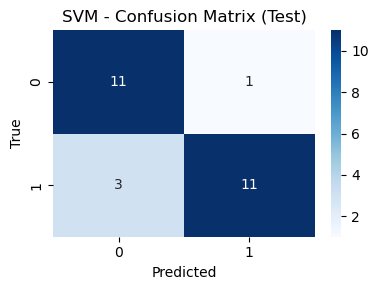

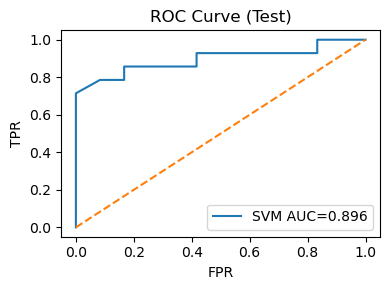

In [46]:
# Step 21: Final Evaluation (Confusion Matrix and ROC Curve on Test Set)
y_pred = best_pipe.predict(X_test)
y_proba = best_pipe.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"{best_name} - Confusion Matrix (Test)")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout(); plt.show()

fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(4,3))
plt.plot(fpr, tpr, label=f"{best_name} AUC={roc_auc_score(y_test, y_proba):.3f}")
plt.plot([0,1], [0,1], "--")
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC Curve (Test)"); plt.legend()
plt.tight_layout(); plt.show()

In [47]:
# Step 22: Extracting Selected Feature Names (Post-Processing + Selection)

# Fit on Train to Extract Names Safely
tmp_pipe = make_pipeline(models["RandomForest"])
tmp_pipe.fit(X_train, y_train)

# Get Feature Names After Preprocessing
def get_feature_names(ct: ColumnTransformer):
    names = []
    for name, trans, cols in ct.transformers_:
        if name == "remainder":
            continue
        if hasattr(trans, "named_steps"):
            last = list(trans.named_steps.values())[-1]
            if hasattr(last, "get_feature_names_out"):
                names.extend(last.get_feature_names_out(cols))
            else:
                names.extend(cols)
        else:
            names.extend(cols)
    return np.array(names, dtype=object)

feat_names_pre = get_feature_names(tmp_pipe.named_steps["prep"])

# REduce to Selected Features
mask = tmp_pipe.named_steps["select"].get_support()
selected_names = feat_names_pre[mask]
len(selected_names), selected_names[:10]

(100,
 array(['DENS_15_AF4', 'DENS_15_C1', 'DENS_15_C2', 'DENS_15_C4',
        'DENS_15_CP1', 'DENS_15_CP2', 'DENS_15_CP4', 'DENS_15_CPZ',
        'DENS_15_CZ', 'DENS_15_F1'], dtype=object))

## Final Results

**Objective:**  
Classify Schizophrenia vs Control subjects using EEG-derived features.

**Dataset:**  
- 38 subjects  
- ~2897 features (high-dimensional, small-sample setting)

**Workflow:**  
- Stratified train/test split  
- Feature scaling  
- Feature selection using SelectKBest (top 100 features)  
- Model training and comparison

**Models evaluated:**  
- Logistic Regression  
- Decision Tree  
- Random Forest  
- Support Vector Machine (SVM)

**Evaluation criteria:**  
- Confusion matrix  
- F1-score  
- ROC–AUC  
- 5-fold stratified cross-validation on the training set

**Main observation:**  
- The **SVM** model achieved the best performance on the held-out test set (highest ROC–AUC and F1-score), and was selected as the final model.

**Summary:**  
- The model shows reasonable separation between classes given the very small dataset, but the results should be considered **exploratory** and **not clinically reliable**.

**Limitations:**  
- Very small sample size with very high feature dimensionality  
- No external validation dataset  

---

## Model Comparison: SVM vs Random Forest

- **Random Forest** achieved a slightly higher *average* ROC–AUC during cross-validation on the training data.  
- **SVM** performed better on the independent test set, with higher ROC–AUC and F1-score.

Since the test set represents **unseen data**, the final model choice was based on test performance. Therefore, **SVM** was selected as the final model.

The difference between cross-validation and test results is expected due to the **small sample size** and **high dimensionality** of the data.